# 1 - Extração de Caracteristicas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from google.colab.patches import cv2_imshow
import os
import cv2 as cv
from skimage.feature import local_binary_pattern
import pandas as pd

In [4]:
!wget /content/Train_Warwick.zip

!wget /content/Test_Warwick.zip

# Extrai o conteúdo do arquivo zip
!unzip Train_Warwick.zip
!unzip Test_Warwick.zip

/content/Train_Warwick.zip: Scheme missing.
/content/Test_Warwick.zip: Scheme missing.
Archive:  Train_Warwick.zip
   creating: Train_4cls_amostra/
   creating: Train_4cls_amostra/0/
  inflating: Train_4cls_amostra/0/46_HER2_61709.png  
  inflating: Train_4cls_amostra/0/46_HER2_64186.png  
  inflating: Train_4cls_amostra/0/13_HER2_10243.png  
  inflating: Train_4cls_amostra/0/46_HER2_58961.png  
  inflating: Train_4cls_amostra/0/46_HER2_64180.png  
  inflating: Train_4cls_amostra/0/46_HER2_55795.png  
  inflating: Train_4cls_amostra/0/18_HER2_25188.png  
  inflating: Train_4cls_amostra/0/13_HER2_11145.png  
  inflating: Train_4cls_amostra/0/13_HER2_2910.png  
  inflating: Train_4cls_amostra/0/01_HER2_4962.png  
  inflating: Train_4cls_amostra/0/18_HER2_30785.png  
  inflating: Train_4cls_amostra/0/13_HER2_11144.png  
  inflating: Train_4cls_amostra/0/01_HER2_4153.png  
  inflating: Train_4cls_amostra/0/57_HER2_6110.png  
  inflating: Train_4cls_amostra/0/01_HER2_7841.png  
  inflating:

## Carregar base de dados

In [29]:
# prompt: carregue a pasta Test_4cl_amostra em uma base de dados de imagens
# ## Carregar base de dados


def load_images_from_folder(folder, category):
  images = []
  for filename in os.listdir(folder):
    img = cv.imread(os.path.join(folder,filename))
    if img is not None:
      images.append((img, filename, category)) # Store image, filename, and category
  return images

train_images = []

for i in range(4):
  # Pass the integer category to the function
  train_images += load_images_from_folder('Train_4cls_amostra/' + str(i) + '/', i)

#train_images

In [33]:
''' separando em treino de validação, separando as imagens de 1 paciente por
categoria (aprox. 30 imagens por paciente) temos ~20% da base de treino
Pacientes escolhidos: 01, 14, 04 e 06'''

dados_treino = []
dados_val = []

for image, filename, category in train_images:
  if filename.startswith('01'):
    dados_val.append((image, filename, category))
  elif filename.startswith('14'):
    dados_val.append((image, filename, category))
  elif filename.startswith('04'):
    dados_val.append((image, filename, category))
  elif filename.startswith('06'):
    dados_val.append((image, filename, category))
  else:
    dados_treino.append((image, filename, category))

len(dados_treino), len(dados_val)
dados_treino

[(array([[[198, 204, 211],
          [196, 209, 217],
          [197, 209, 215],
          ...,
          [226, 227, 225],
          [225, 226, 224],
          [219, 222, 230]],
  
         [[195, 204, 207],
          [195, 206, 210],
          [194, 205, 209],
          ...,
          [225, 225, 225],
          [224, 224, 224],
          [221, 222, 232]],
  
         [[198, 210, 212],
          [199, 208, 211],
          [197, 206, 209],
          ...,
          [223, 222, 224],
          [221, 220, 224],
          [220, 221, 231]],
  
         ...,
  
         [[217, 223, 228],
          [221, 224, 229],
          [221, 224, 228],
          ...,
          [228, 227, 229],
          [232, 230, 229],
          [233, 233, 227]],
  
         [[218, 223, 226],
          [217, 220, 225],
          [217, 220, 224],
          ...,
          [223, 225, 225],
          [226, 227, 225],
          [231, 229, 228]],
  
         [[218, 222, 223],
          [220, 221, 225],
          [219, 221, 222

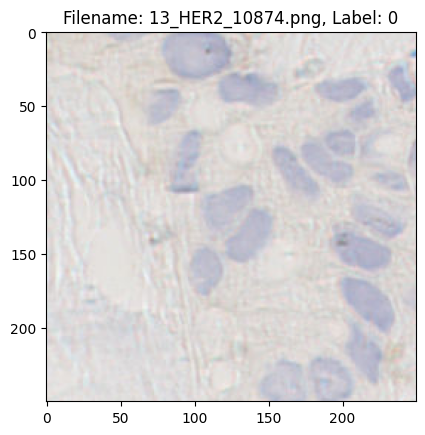

Image shape: (250, 250, 3)
Filename: 13_HER2_10874.png
Label: 0
--------------------


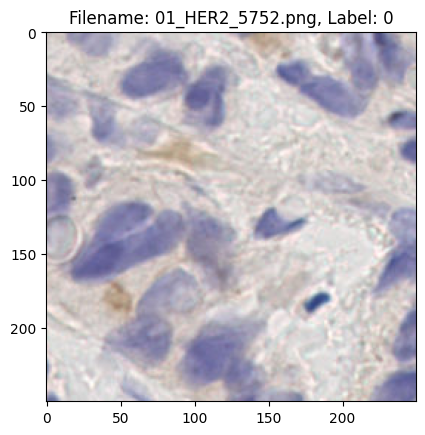

Image shape: (250, 250, 3)
Filename: 01_HER2_5752.png
Label: 0
--------------------


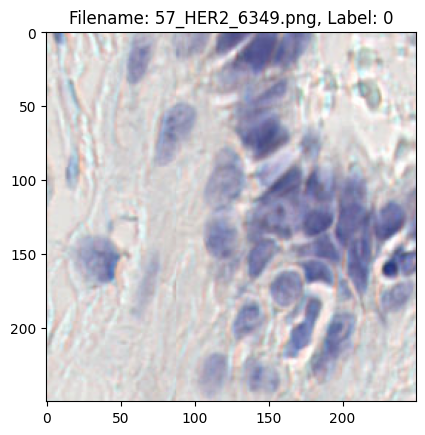

Image shape: (250, 250, 3)
Filename: 57_HER2_6349.png
Label: 0
--------------------


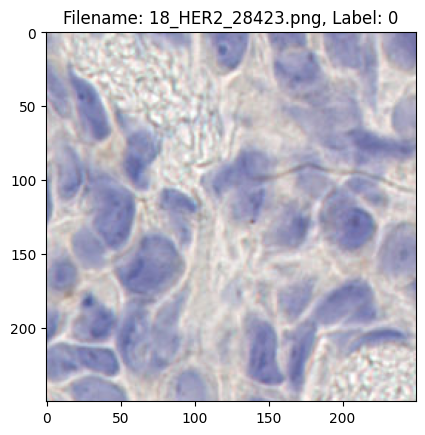

Image shape: (250, 250, 3)
Filename: 18_HER2_28423.png
Label: 0
--------------------


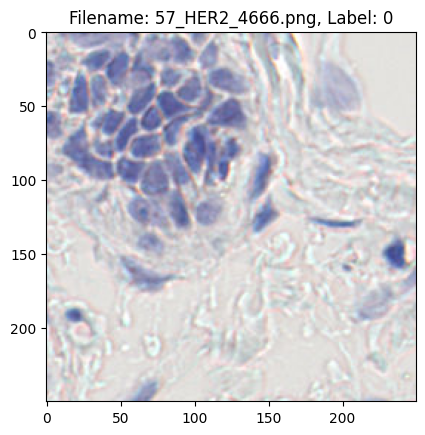

Image shape: (250, 250, 3)
Filename: 57_HER2_4666.png
Label: 0
--------------------


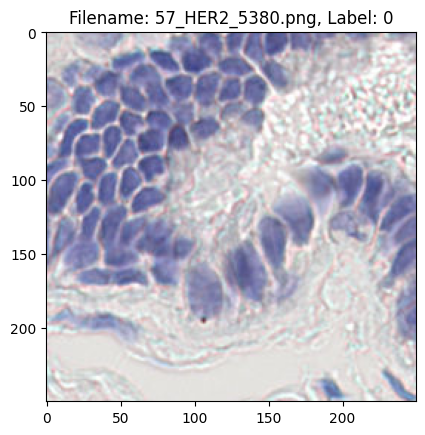

Image shape: (250, 250, 3)
Filename: 57_HER2_5380.png
Label: 0
--------------------


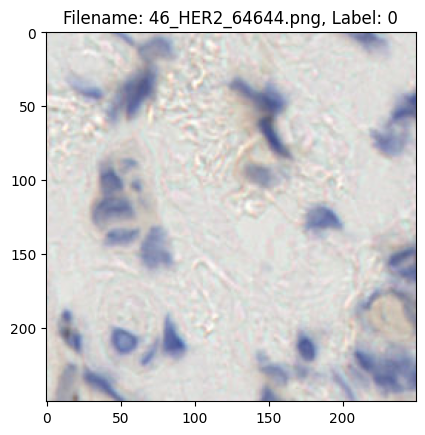

Image shape: (250, 250, 3)
Filename: 46_HER2_64644.png
Label: 0
--------------------


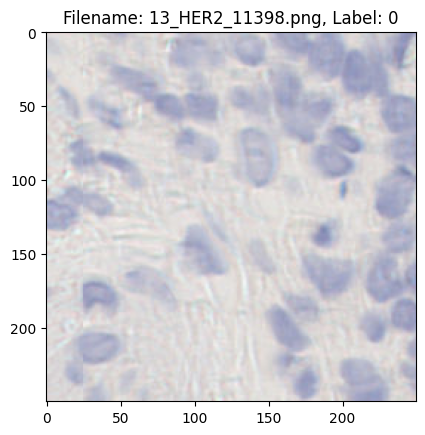

Image shape: (250, 250, 3)
Filename: 13_HER2_11398.png
Label: 0
--------------------


KeyboardInterrupt: 

In [11]:
# exibindo as imagens com o nome do arquivo e categoria

import matplotlib.pyplot as plt

# Assuming your tuple structure is (image, filename, label)
for image, filename, category in train_images:
    # Display the image
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))  # Convert to RGB for Matplotlib
    plt.title(f"Filename: {filename}, Label: {category}")
    plt.show()

    # Print other information
    print(f"Image shape: {image.shape}")
    print(f"Filename: {filename}")
    print(f"Label: {category}")
    print("-" * 20)  # Separator

In [34]:
#Extrai características utilizando LBP

def extract_lbp_features(image):
    gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    radius = 3  # Adjust as needed
    n_points = 8 * radius  # Adjust as needed
    lbp = local_binary_pattern(gray_image, n_points, radius, method='uniform')
    # Calculate histogram to represent the LBP features
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp, density=True, bins=n_bins, range=(0, n_bins))
    return hist

# Extrai caracteristica e salva em lista junto com a categoria e filename
data_treino = []
data_val = []

#Base treino
for image, filename, category in dados_treino:
    features_lbp = extract_lbp_features(image)
    data_treino.append(np.concatenate(([filename],[category], features_lbp)))

#Base validação
for image, filename, category in dados_val:
    features_lbp_val = extract_lbp_features(image)
    data_val.append(np.concatenate(( [filename],[category], features_lbp_val)))


#cria um dataframe pandas e salva em csv
#base treino
colunas = ['filename', 'category'] + [f'lbp_{i}' for i in range(len(features_lbp))]
df_treino_lbp = pd.DataFrame(data_treino, columns=colunas)

df_treino_lbp.to_csv('lbp_features.csv', index=False)

#base validação
colunas = ['filename', 'category', ] + [f'lbp_{i}' for i in range(len(features_lbp_val))]
df_val_lbp = pd.DataFrame(data_val, columns=colunas)

df_val_lbp.to_csv('lbp_features_val.csv', index=False)

In [37]:
#Extrai características utilizando CNN VGG16

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model


# Carrega o modelo VGG16 pré-treinado (sem a camada de classificação)
base_model = VGG16(weights='imagenet', include_top=True)

# Cria um novo modelo que gera as características da camada 'fc2'
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

def extract_features(img):
    # Redimensiona a imagem para o tamanho de entrada do VGG16 (224x224)
    img = cv.resize(img, (224, 224))
    # Converte a imagem para um array NumPy
    #x = image.img_to_array(img)
    # Expande as dimensões para criar um batch de uma única imagem
    x = np.expand_dims(img, axis=0)
    # Pré-processa a imagem de acordo com o VGG16
    x = preprocess_input(x)
    # Extrai as características usando o modelo
    features = model.predict(x)
    # Retorna as características como um array NumPy
    return features[0]

features_list = []
features_list_val = []

# BASE DE TREINO
for image, filename, category in dados_treino:
    features_cnn = extract_features(image)
    features_list.append(np.concatenate(( [filename],[category], features_cnn)))

# BASE DE VALIDAÇÃO
for image, filename, category in dados_val:
    features_cnn_val = extract_features(image)
    features_list_val.append(np.concatenate(( [filename],[category], features_cnn_val)))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━

In [38]:
# Create DataFrame and save to CSV
#BASE TREINO
num_features = features_cnn.shape[0] # Get the number of features from features_cnn
colunas_cnn = ['filename'] + ['category']+  [f'cnn_{i}' for i in range(num_features)]
df_treino_cnn = pd.DataFrame(features_list, columns=colunas_cnn)

df_treino_cnn.to_csv('cnn_features.csv', index=False)

# BASE VALIDAÇÃO
num_features = features_cnn_val.shape[0] # Get the number of features from features_cnn
colunas_cnn = ['filename'] + ['category'] + [f'cnn_{i}' for i in range(num_features)]
df_val_cnn = pd.DataFrame(features_list_val, columns=colunas_cnn)

df_val_cnn.to_csv('cnn_features_val.csv', index=False)

---
##TREINAMENTO DOS MODELOS

As metricas calculadas nesta etapa foram usadas para o ajuste dos hiperparametros e não serão necessariamente usadas para a escolha do melhor modelo.


In [39]:
#função para avaliação de resultados

def avaliar_resultados(y_real, y_pred):
    # Avaliando a acurácia
    accuracy = accuracy_score(y_real, y_pred)
    print(f"Acurácia do modelo: {accuracy}")

    # Exibindo a matriz de confusão
    cm = confusion_matrix(y_real, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

    # Calculando as métricas por classe e a média macro
    report = classification_report(y_real, y_pred, output_dict=True)
    sensibilidade_macro = report['macro avg']['recall']  # Sensibilidade (Recall) macro
    especificidade_macro = report['macro avg']['precision']  # Especificidade (Precision) macro
    f1_score_macro = report['macro avg']['f1-score']  # F1-Score macro

    print(f"Sensibilidade (Macro): {sensibilidade_macro}")
    print(f"Especificidade (Macro): {especificidade_macro}")
    print(f"F1-Score (Macro): {f1_score_macro}")

    return {
        "acuracia": accuracy,
        "sensibilidade_macro": sensibilidade_macro,
        "especificidade_macro": especificidade_macro,
        "f1_score_macro": f1_score_macro
    }

###RANDOM FOREST


#### LBP

In [59]:
#LBP

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

#df_treino_lbp = pd.read_csv('lbp_features.csv')

# Separate features (X) and target (y)
X_train = df_treino_lbp.drop(['filename', 'category'], axis=1)  # Caracteristicas
y_train = df_treino_lbp['category']     # alvo

# criando e treinando o modelo
rf_model_lbp = RandomForestClassifier(n_estimators=500,
                                  max_depth=17,
                                  min_samples_split=8,
                                  min_samples_leaf=5,
                                  max_features='sqrt')
#rf_model = RandomForestClassifier()

rf_model_lbp.fit(X_train, y_train)

RandomForestClassifier(max_depth=17, min_samples_leaf=5, min_samples_split=8,
                       n_estimators=500)

Acurácia do modelo: 0.7672413793103449


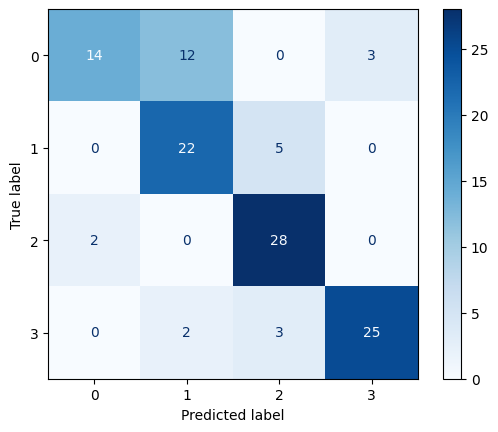

Sensibilidade (Macro): 0.7660600255427842
Especificidade (Macro): 0.7891865079365079
F1-Score (Macro): 0.7577971836592525


In [60]:
# Avaliando o modelo para o tunning dos hiperparametros
y_pred = rf_model_lbp.predict(df_val_lbp.drop(['category', 'filename'], axis=1))
resultado_tunning_rf_lbp = avaliar_resultados(df_val_lbp['category'], y_pred)

#### CNN

In [63]:
# CNN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#df_treino_cnn = pd.read_csv('cnn_features.csv')

# Separate features (X) and target (y)
X_train = df_treino_cnn.drop(['filename','category'], axis=1)  # Caracteristicas
y_train = df_treino_cnn['category']     # alvo

# instanciando com hiperparametros
rf_model_cnn = RandomForestClassifier(n_estimators=500,
                                  max_depth=17,
                                  min_samples_split=8,
                                  min_samples_leaf=5,
                                  max_features='sqrt')
#rf_model = RandomForestClassifier()

#trainando o modelo
rf_model_cnn.fit(X_train, y_train)


RandomForestClassifier(max_depth=17, min_samples_leaf=5, min_samples_split=8,
                       n_estimators=500)

Acurácia do modelo: 0.8448275862068966


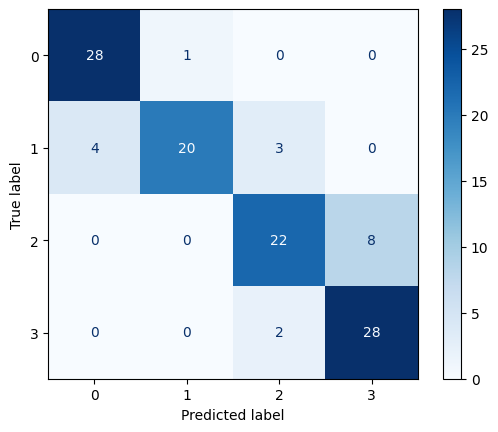

Sensibilidade (Macro): 0.8432311621966795
Especificidade (Macro): 0.8549933862433862
F1-Score (Macro): 0.8429451983162078


In [64]:
# Avaliando o modelo para o tunning dos hiperparametros
y_pred = rf_model_cnn.predict(df_val_cnn.drop(['filename','category'], axis=1))
resultado_tunning_rf_cnn = avaliar_resultados(df_val_cnn['category'], y_pred)

## SVM

#### LBP

In [74]:
# LBP
from sklearn.svm import SVC

# Separate features (X) and target (y)
X_train = df_treino_lbp.drop(['filename','category'], axis=1)  # Caracteristicas
y_train = df_treino_lbp['category']     # alvo

#instanciando com hiperparametros
svm_model_lbp = SVC(kernel='rbf', C=700, gamma = 8, decision_function_shape='ovo')


#treinando o modelo
svm_model_lbp.fit(X_train, y_train)



SVC(C=700, decision_function_shape='ovo', gamma=8)

Acurácia do modelo: 0.8362068965517241


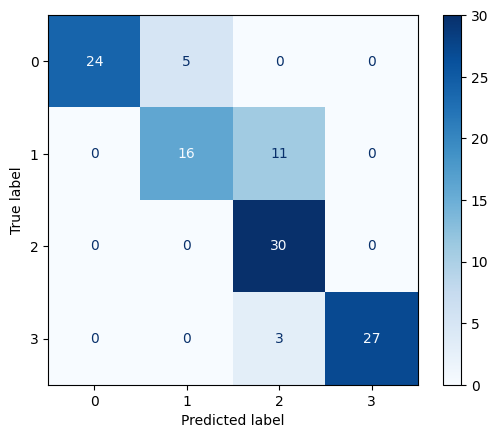

Sensibilidade (Macro): 0.830044699872286
Especificidade (Macro): 0.8609307359307359
F1-Score (Macro): 0.8326265689721499


In [75]:
# Avaliando o modelo para o tunning dos hiperparametros
y_pred = svm_model_lbp.predict(df_val_lbp.drop(['filename','category'], axis=1))
resultado_tunning_svm_lbp = avaliar_resultados(df_val_lbp['category'], y_pred)

#### CNN

In [85]:
#CNN
# Separate features (X) and target (y)
X_train = df_treino_cnn.drop(['filename','category'], axis=1)  # Caracteristicas
y_train = df_treino_cnn['category']     # alvo

#instanciando com hiperparametros
svm_model_cnn = SVC(kernel='linear', C=280, gamma = 8, decision_function_shape='ovr')

#treinando o modelo
svm_model_cnn.fit(X_train, y_train)

SVC(C=280, gamma=8, kernel='linear')

Acurácia do modelo: 0.8362068965517241


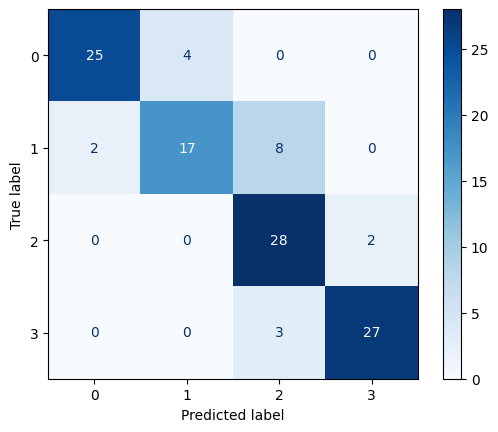

Sensibilidade (Macro): 0.8312579821200511
Especificidade (Macro): 0.8461082340392685
F1-Score (Macro): 0.8320097290942907


In [86]:
# Avaliando o modelo para o tunning dos hiperparametros
y_pred = svm_model_cnn.predict(df_val_cnn.drop(['filename','category'], axis=1))
resultado_tunning_svm_cnn = avaliar_resultados(df_val_cnn['category'], y_pred)

## RNA

#### LBP

In [95]:
#LBP
from sklearn.neural_network import MLPClassifier

# Separate features (X) and target (y) - treinamento
X_train = df_treino_lbp.drop(['filename','category'], axis=1)  # Caracteristicas
y_train = df_treino_lbp['category']     # alvo

#instanciando com hiperparametros
rna_model_lbp = MLPClassifier(hidden_layer_sizes=(100,50),
                            learning_rate='constant',
                              learning_rate_init=0.001,
                            activation='relu',
                          solver='adam',
                          alpha=0.0001,
                          batch_size='auto',
                          max_iter=5000
                          )

#treinando modelo
rna_model_lbp.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=5000)

Acurácia do modelo: 0.8017241379310345


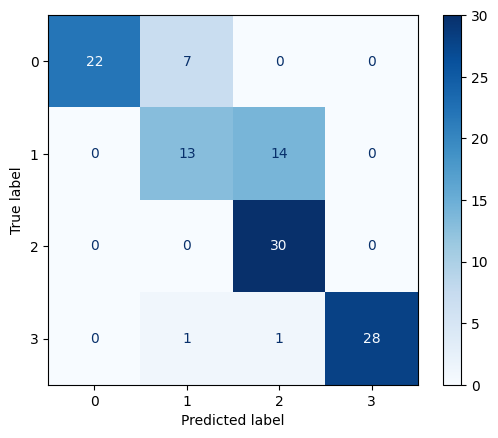

Sensibilidade (Macro): 0.7933588761174968
Especificidade (Macro): 0.8214285714285714
F1-Score (Macro): 0.7924822515212981


In [96]:
# Avaliando o modelo para o tunning dos hiperparametros
y_pred = rna_model_lbp.predict(df_val_lbp.drop(['filename','category'], axis=1))
resultado_tunning_rna_lbp = avaliar_resultados(df_val_lbp['category'], y_pred)

#### CNN

In [97]:
# CNN
# Separate features (X) and target (y) - treinamento
X_train = df_treino_cnn.drop(['filename','category'], axis=1)  # Caracteristicas
y_train = df_treino_cnn['category']     # alvo

#instanciando com hiperparametros
rna_model_cnn = MLPClassifier(hidden_layer_sizes=(100,50),
                            learning_rate='constant',
                              learning_rate_init=0.001,
                            activation='relu',
                          solver='adam',
                          alpha=0.0001,
                          batch_size='auto',
                          max_iter=5000
                          )

#treinando modelo
rna_model_cnn.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=5000)

Acurácia do modelo: 0.8017241379310345


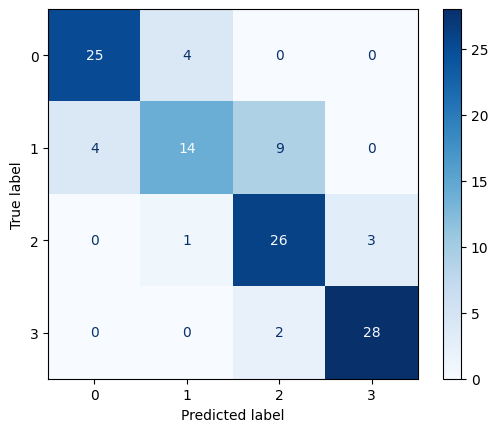

Sensibilidade (Macro): 0.79514687100894
Especificidade (Macro): 0.8012098949836787
F1-Score (Macro): 0.7912292018903688


In [98]:
# Avaliando o modelo para o tunning dos hiperparametros
y_pred = rna_model_cnn.predict(df_val_cnn.drop(['filename','category'], axis=1))
resultado_tunning_rna_cnn = avaliar_resultados(df_val_cnn['category'], y_pred)

# APLICAÇÃO NA BASE DE TESTE


In [54]:
# Carregamento da base de testes
test_images = []

for i in range(4):
  test_images += load_images_from_folder('Test_4cl_amostra/' + str(i) + '/', i)

#test_images

In [56]:
#Extrai características utilizando LBP e salva em lista junto com a categoria
data_test = []

for image, filename, category in test_images:
    features_lbp_test = extract_lbp_features(image)
    data_test.append(np.concatenate(([filename],[category], features_lbp_test)))

#cria um dataframe pandas e salva em csv
colunas = ['filename'] + ['category'] + [f'lbp_{i}' for i in range(len(features_lbp_test))]
df_test_lbp = pd.DataFrame(data_test, columns=colunas)
df_test_lbp.to_csv('lbp_features_test.csv', index=False)

In [57]:
#Extrai características utilizando CNN e salva em lista junto com a categoryegoria e filename
features_list_test = []

for image, filename, category in test_images:
    features_cnn_test = extract_features(image)
    features_list_test.append(np.concatenate(([filename], [category], features_cnn_test)))

# Create DataFrame and save to CSV
num_features = features_cnn_test.shape[0] # Get the number of features from features_cnn
colunas_cnn = ['filename','category'] + [f'cnn_{i}' for i in range(num_features)]
df_test_cnn = pd.DataFrame(features_list_test, columns=colunas_cnn)

df_test_cnn.to_csv('cnn_features_test.csv', index=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━

Random Forest - LBP
Acurácia do modelo: 0.6954177897574124


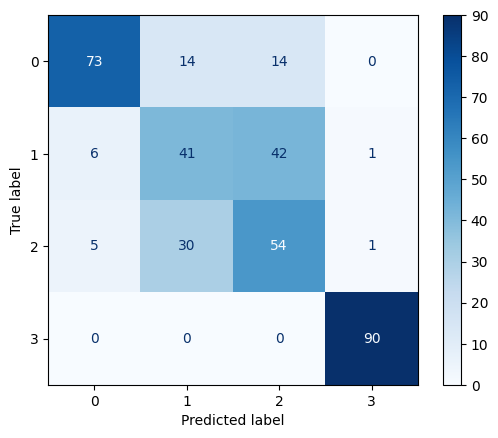

Sensibilidade (Macro): 0.6945819581958196
Especificidade (Macro): 0.7051426301745995
F1-Score (Macro): 0.6966929016929018

Random Forest - CNN
Acurácia do modelo: 0.7762803234501348


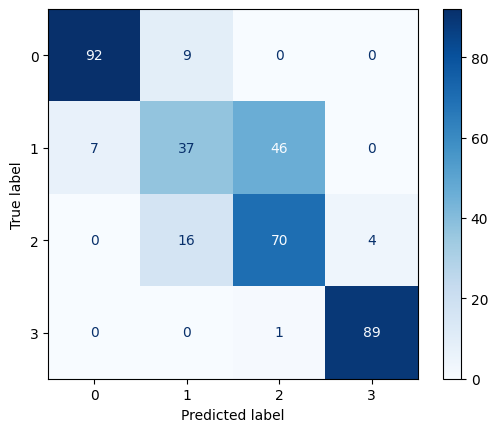

Sensibilidade (Macro): 0.7721672167216722
Especificidade (Macro): 0.7703367421109357
F1-Score (Macro): 0.7639620508267579

SVM - LBP
Acurácia do modelo: 0.6738544474393531


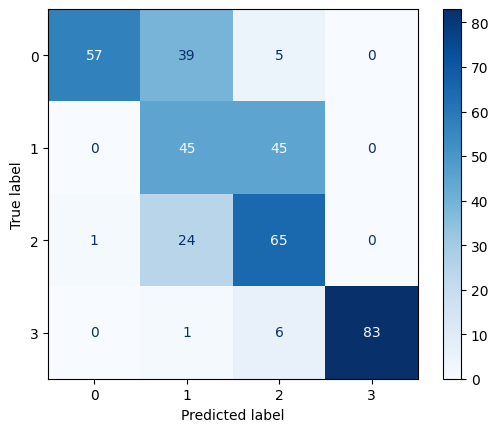

Sensibilidade (Macro): 0.6772002200220022
Especificidade (Macro): 0.7331981850078828
F1-Score (Macro): 0.6862234387345749

SVM - CNN
Acurácia do modelo: 0.7547169811320755


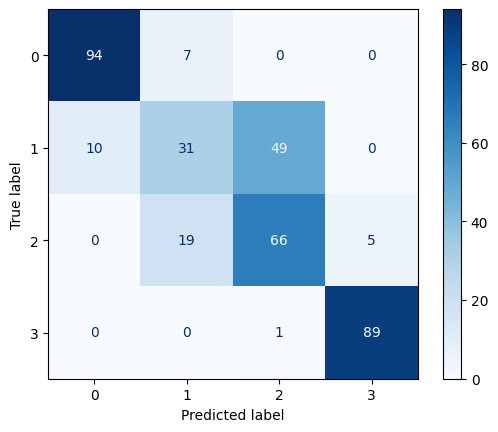

Sensibilidade (Macro): 0.7493399339933994
Especificidade (Macro): 0.7408699577121595
F1-Score (Macro): 0.7367524703979133

RNA - LBP
Acurácia do modelo: 0.6415094339622641


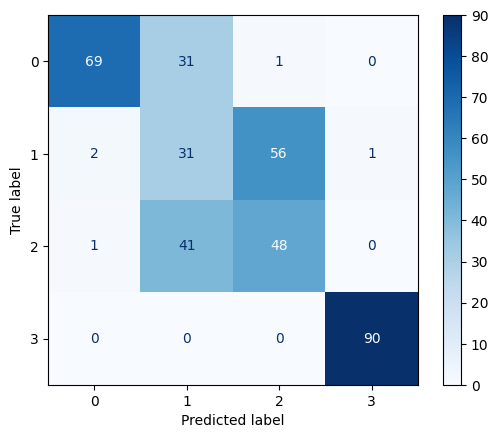

Sensibilidade (Macro): 0.6402365236523653
Especificidade (Macro): 0.6763645133183969
F1-Score (Macro): 0.6514285537542445

RNA - CNN
Acurácia do modelo: 0.7358490566037735


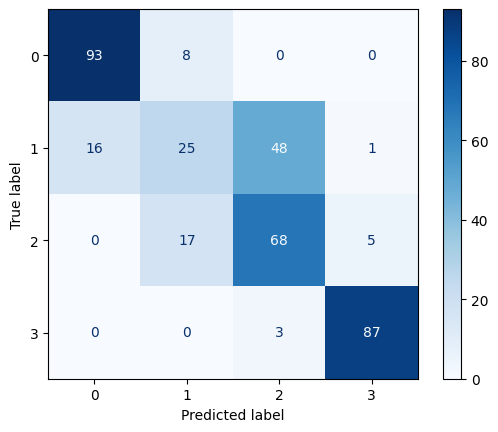

Sensibilidade (Macro): 0.7301980198019802
Especificidade (Macro): 0.7150308628926563
F1-Score (Macro): 0.7110986295843931


In [99]:

#faz as predições nas bases de teste
y_pred_rf_lbp = rf_model_lbp.predict(df_test_lbp.drop(['filename','category'], axis=1))
y_pred_rf_cnn = rf_model_cnn.predict(df_test_cnn.drop(['filename','category'], axis=1))

y_pred_svm_lbp = svm_model_lbp.predict(df_test_lbp.drop(['filename','category'], axis=1))
y_pred_svm_cnn = svm_model_cnn.predict(df_test_cnn.drop(['filename','category'], axis=1))

y_pred_rna_lbp = rna_model_lbp.predict(df_test_lbp.drop(['filename','category'], axis=1))
y_pred_rna_cnn = rna_model_cnn.predict(df_test_cnn.drop(['filename','category'], axis=1))

# avaliação dos resultados
print("Random Forest - LBP")
resultados_rf_lbp = avaliar_resultados(df_test_lbp['category'], y_pred_rf_lbp)
print("\nRandom Forest - CNN")
resultados_rf_cnn = avaliar_resultados(df_test_cnn['category'], y_pred_rf_cnn)

print("\nSVM - LBP")
resultados_svm_lbp = avaliar_resultados(df_test_lbp['category'], y_pred_svm_lbp)
print("\nSVM - CNN")
resultados_svm_cnn = avaliar_resultados(df_test_cnn['category'], y_pred_svm_cnn)

print("\nRNA - LBP")
resultados_rna_lbp = avaliar_resultados(df_test_lbp['category'], y_pred_rna_lbp)
print("\nRNA - CNN")
resultados_rna_cnn = avaliar_resultados(df_test_cnn['category'], y_pred_rna_cnn)